In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pylab as pl
import scipy as sp
from scipy import signal
from statsmodels.tsa.stattools import acf
from functools import partial
import math
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.stattools import jarque_bera

## Data preparation

## TODO: stationary test/more detailed tests on the time series properties (like fat tails, etc.)

In [67]:
sns.set_theme(style="whitegrid")

tickers = ["GLD", "PAXG-USD", "DX-Y.NYB"]
start_date = "2020-01-01"
end_date = "2025-03-20"

raw_data = yf.download(tickers, start=start_date, end=end_date)['Close']


[*********************100%***********************]  3 of 3 completed


In [68]:
# Clean and Align the Data (The "Inner Join" logic)
# Traditional markets are closed on weekends/holidays, resulting in NaNs.
# Using .dropna() automatically drops the crypto weekend data, aligning everything perfectly.
aligned_data = raw_data.dropna()
aligned_data.columns = ['US Dollar Index', 'Physical Gold', 'PAX Gold']

# Calculate Daily Log-Returns
# Formula: ln(P_t / P_{t-1})
# !!!! attention, we *100 to scale the data

log_returns = np.log(aligned_data / aligned_data.shift(1)).dropna()
gold_array = log_returns['Physical Gold'].values*100
paxg_array = log_returns['PAX Gold'].values*100
usd_array = log_returns['US Dollar Index'].values*100
print(f"Shape of the NumPy arrays: {gold_array.shape} days of trading.")


Shape of the NumPy arrays: (1309,) days of trading.


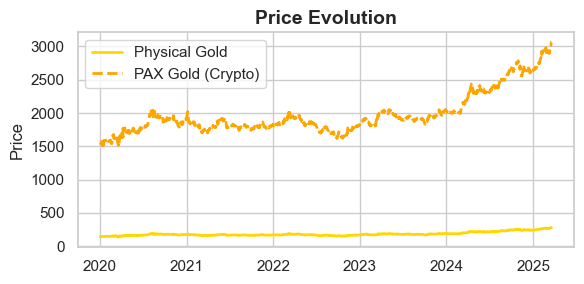

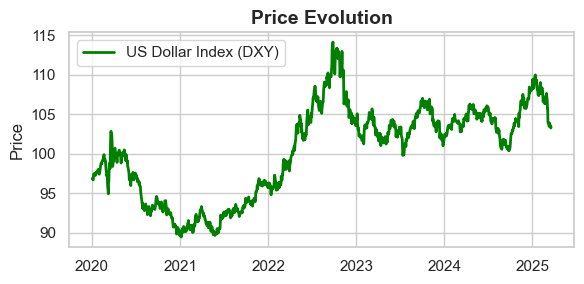

In [70]:
plt.figure(figsize=(6, 3))
plt.plot(aligned_data['Physical Gold'].index, aligned_data['Physical Gold'], label='Physical Gold', color='gold', linewidth=2)
plt.plot(aligned_data.index, aligned_data['PAX Gold'], label='PAX Gold (Crypto)', color='orange', linestyle='--', linewidth=2)
plt.title('Price Evolution', fontsize=14, fontweight='bold')
plt.ylabel('Price', fontsize=12)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 3))
plt.plot(aligned_data.index, aligned_data['US Dollar Index'], label='US Dollar Index (DXY)', color='green', linewidth=2)

plt.title('Price Evolution', fontsize=14, fontweight='bold')
plt.ylabel('Price', fontsize=12)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

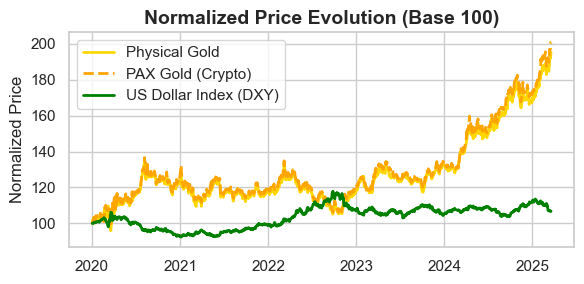

In [71]:
normalized_prices = (aligned_data / aligned_data.iloc[0]) * 100

plt.figure(figsize=(6, 3))
plt.plot(normalized_prices.index, normalized_prices['Physical Gold'], label='Physical Gold', color='gold', linewidth=2)
plt.plot(normalized_prices.index, normalized_prices['PAX Gold'], label='PAX Gold (Crypto)', color='orange', linestyle='--', linewidth=2)
plt.plot(normalized_prices.index, normalized_prices['US Dollar Index'], label='US Dollar Index (DXY)', color='green', linewidth=2)

plt.title('Normalized Price Evolution (Base 100)', fontsize=14, fontweight='bold')
plt.ylabel('Normalized Price', fontsize=12)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [72]:
print("In terms of daily log-return, we cannot say that \nthe tendance of the price of gold or PAX Gold is increasing, as we see in the figures aboves.")
print(np.mean(log_returns['Physical Gold']), np.mean(log_returns['PAX Gold']), np.mean(log_returns['US Dollar Index']))

In terms of daily log-return, we cannot say that 
the tendance of the price of gold or PAX Gold is increasing, as we see in the figures aboves.
0.0005112910648136212 0.00053329696557254 5.0215190406672586e-05


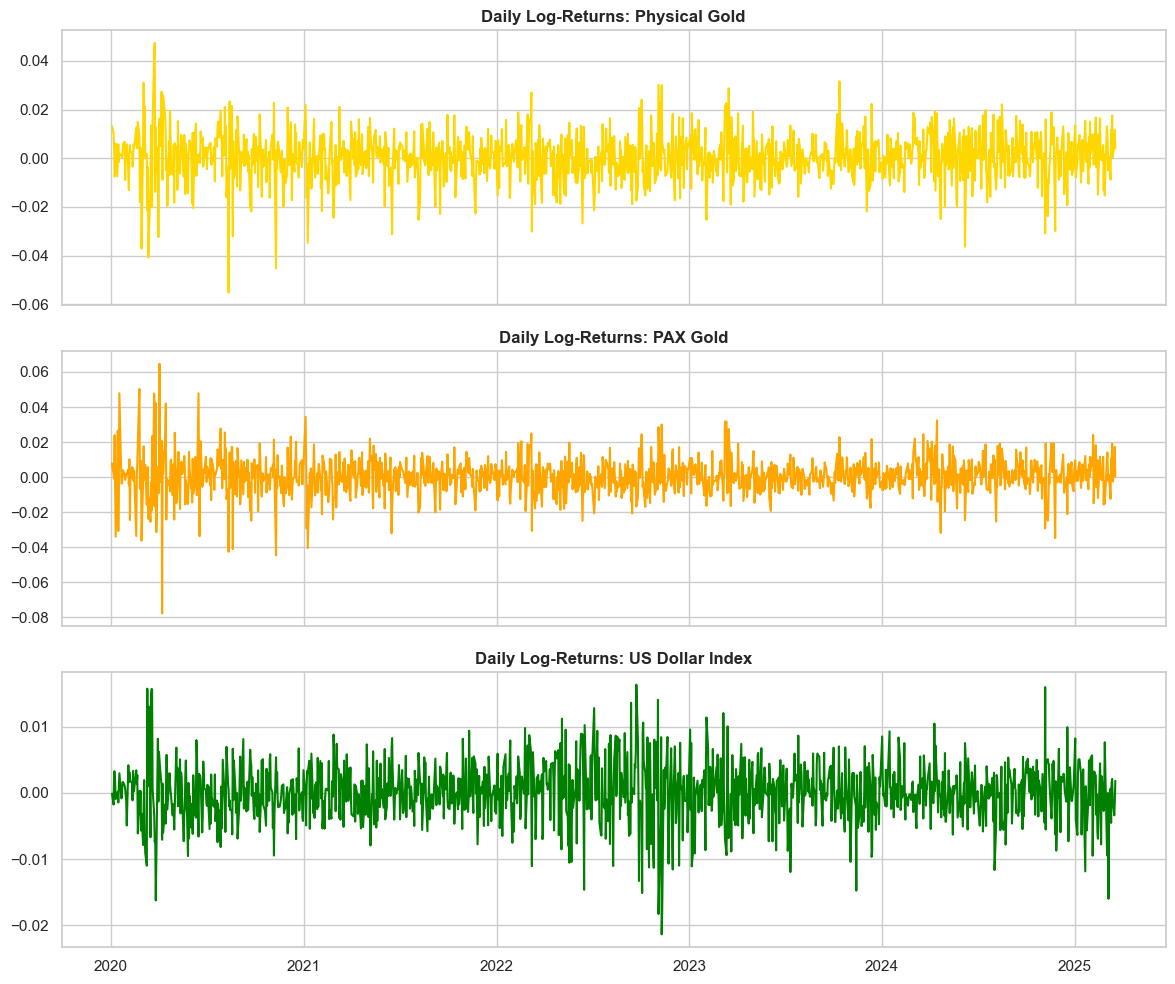

In [73]:
# log return
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(log_returns.index, log_returns['Physical Gold'], color='gold')
axes[0].set_title('Daily Log-Returns: Physical Gold', fontweight='bold')

axes[1].plot(log_returns.index, log_returns['PAX Gold'], color='orange')
axes[1].set_title('Daily Log-Returns: PAX Gold', fontweight='bold')

axes[2].plot(log_returns.index, log_returns['US Dollar Index'], color='green')
axes[2].set_title('Daily Log-Returns: US Dollar Index', fontweight='bold')

plt.tight_layout()
plt.show()

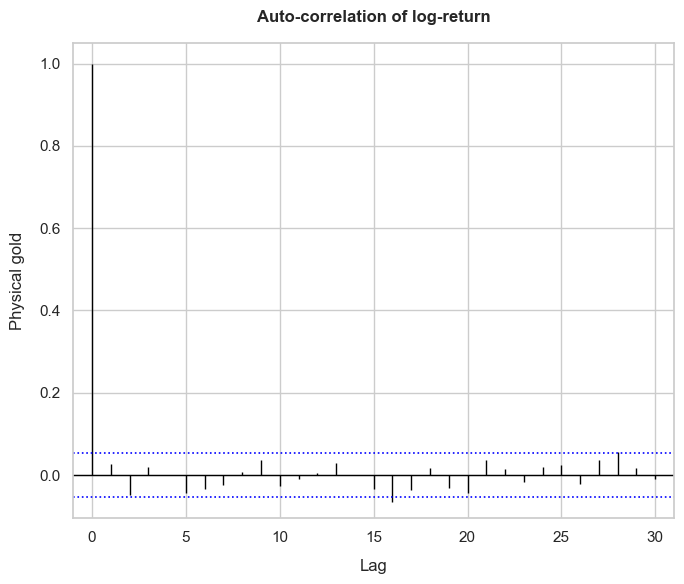

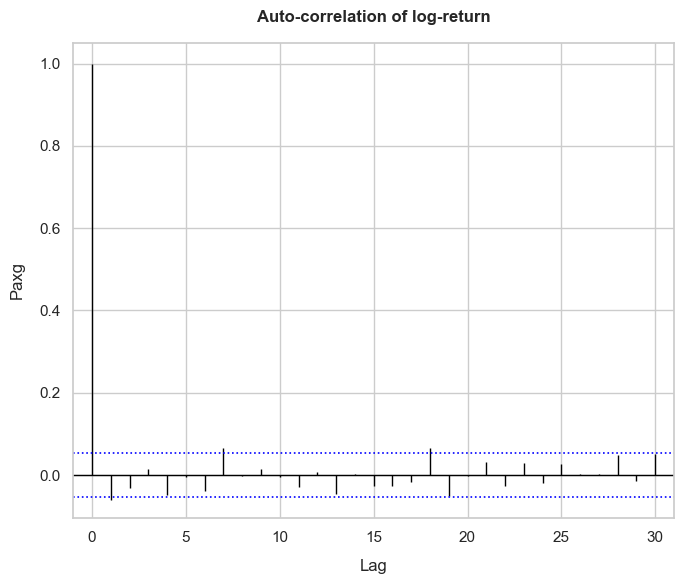

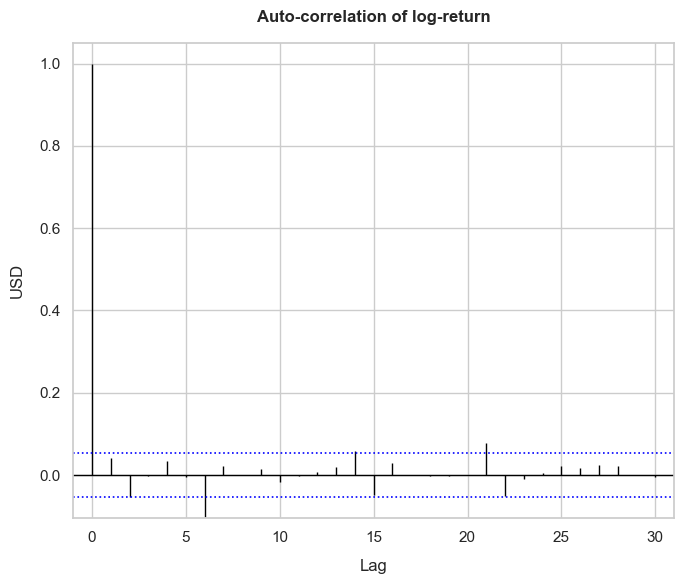

In [74]:
# Fonction d’autocovariance échantillonnale

nlags = 30

# gold 
gold_valeurs_acf = acf(gold_array, nlags=nlags, fft=True)
lags = np.arange(nlags + 1)

N = len(gold_array)
intervalle_confiance = 1.96 / np.sqrt(N)

plt.figure(figsize=(7, 6))

plt.vlines(x=lags, ymin=0, ymax=gold_valeurs_acf, color='black', linewidth=1)
plt.axhline(y=0, color='black', linewidth=1)

plt.axhline(y=intervalle_confiance, color='blue', linestyle=':', linewidth=1.2)
plt.axhline(y=-intervalle_confiance, color='blue', linestyle=':', linewidth=1.2)


plt.title("Auto-correlation of log-return", fontweight='bold', pad=15)
plt.ylabel("Physical gold", labelpad=10) 
plt.xlabel("Lag", labelpad=10)


plt.ylim(min(-0.1, -intervalle_confiance - 0.05), 1.05)
plt.xlim(-1, nlags + 1)


ax = plt.gca()
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

plt.tight_layout()
plt.show()


# paxg 
paxg_valeurs_acf = acf(paxg_array, nlags=nlags, fft=True)
lags = np.arange(nlags + 1)

N = len(paxg_array)
intervalle_confiance = 1.96 / np.sqrt(N)

plt.figure(figsize=(7, 6))

plt.vlines(x=lags, ymin=0, ymax=paxg_valeurs_acf, color='black', linewidth=1)
plt.axhline(y=0, color='black', linewidth=1)

plt.axhline(y=intervalle_confiance, color='blue', linestyle=':', linewidth=1.2)
plt.axhline(y=-intervalle_confiance, color='blue', linestyle=':', linewidth=1.2)

plt.title("Auto-correlation of log-return", fontweight='bold', pad=15)
plt.ylabel("Paxg", labelpad=10) 
plt.xlabel("Lag", labelpad=10)


plt.ylim(min(-0.1, -intervalle_confiance - 0.05), 1.05)
plt.xlim(-1, nlags + 1)


ax = plt.gca()
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

plt.tight_layout()
plt.show()

# usd
usd_valeurs_acf = acf(usd_array, nlags=nlags, fft=True)
lags = np.arange(nlags + 1)

N = len(usd_array)
intervalle_confiance = 1.96 / np.sqrt(N)

plt.figure(figsize=(7, 6))

plt.vlines(x=lags, ymin=0, ymax=usd_valeurs_acf, color='black', linewidth=1)
plt.axhline(y=0, color='black', linewidth=1)

plt.axhline(y=intervalle_confiance, color='blue', linestyle=':', linewidth=1.2)
plt.axhline(y=-intervalle_confiance, color='blue', linestyle=':', linewidth=1.2)


plt.title("Auto-correlation of log-return", fontweight='bold', pad=15)
plt.ylabel("USD", labelpad=10) 
plt.xlabel("Lag", labelpad=10)


plt.ylim(min(-0.1, -intervalle_confiance - 0.05), 1.05)
plt.xlim(-1, nlags + 1)


ax = plt.gca()
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

plt.tight_layout()
plt.show()

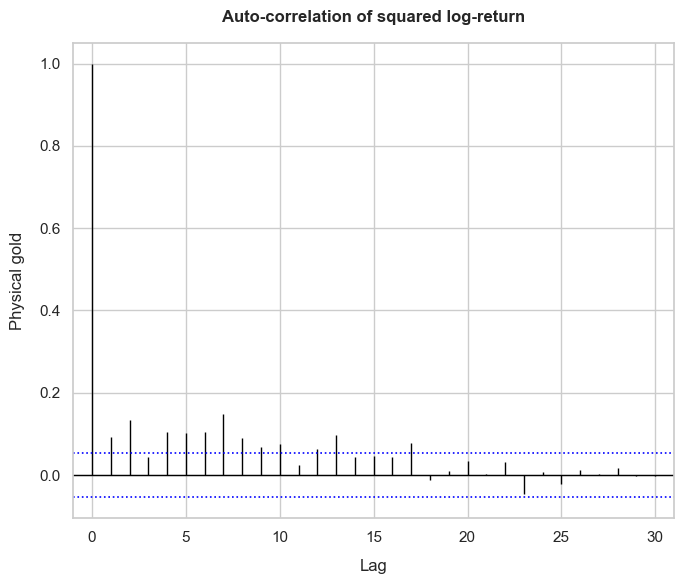

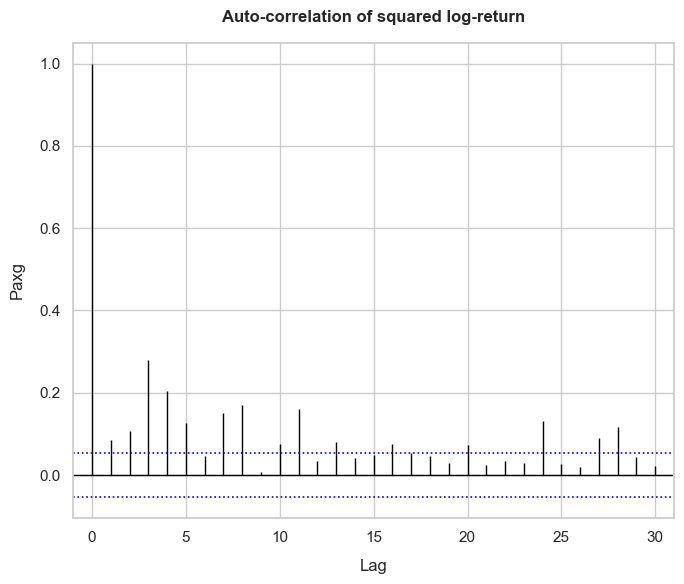

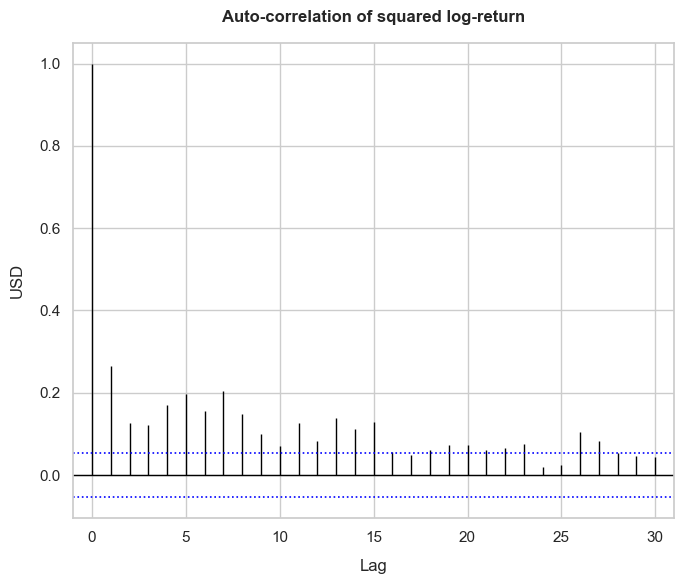

In [75]:
nlags = 30

# gold 
gold_valeurs_acf2 = acf(gold_array**2, nlags=nlags, fft=True)
lags = np.arange(nlags + 1)

N = len(gold_array)
intervalle_confiance = 1.96 / np.sqrt(N)

plt.figure(figsize=(7, 6))

plt.vlines(x=lags, ymin=0, ymax=gold_valeurs_acf2, color='black', linewidth=1)
plt.axhline(y=0, color='black', linewidth=1)

plt.axhline(y=intervalle_confiance, color='blue', linestyle=':', linewidth=1.2)
plt.axhline(y=-intervalle_confiance, color='blue', linestyle=':', linewidth=1.2)


plt.title("Auto-correlation of squared log-return", fontweight='bold', pad=15)
plt.ylabel("Physical gold", labelpad=10) 
plt.xlabel("Lag", labelpad=10)


plt.ylim(min(-0.1, -intervalle_confiance - 0.05), 1.05)
plt.xlim(-1, nlags + 1)


ax = plt.gca()
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

plt.tight_layout()
plt.show()


# paxg 
paxg_valeurs_acf2 = acf(paxg_array**2, nlags=nlags, fft=True)
plt.figure(figsize=(7, 6))

plt.vlines(x=lags, ymin=0, ymax=paxg_valeurs_acf2, color='black', linewidth=1)
plt.axhline(y=0, color='black', linewidth=1)

plt.axhline(y=intervalle_confiance, color='blue', linestyle=':', linewidth=1.2)
plt.axhline(y=-intervalle_confiance, color='blue', linestyle=':', linewidth=1.2)

plt.title("Auto-correlation of squared log-return", fontweight='bold', pad=15)
plt.ylabel("Paxg", labelpad=10) 
plt.xlabel("Lag", labelpad=10)


plt.ylim(min(-0.1, -intervalle_confiance - 0.05), 1.05)
plt.xlim(-1, nlags + 1)


ax = plt.gca()
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

plt.tight_layout()
plt.show()

# usd
usd_valeurs_acf2 = acf(usd_array**2, nlags=nlags, fft=True)


plt.figure(figsize=(7, 6))

plt.vlines(x=lags, ymin=0, ymax=usd_valeurs_acf2, color='black', linewidth=1)
plt.axhline(y=0, color='black', linewidth=1)

plt.axhline(y=intervalle_confiance, color='blue', linestyle=':', linewidth=1.2)
plt.axhline(y=-intervalle_confiance, color='blue', linestyle=':', linewidth=1.2)


plt.title("Auto-correlation of squared log-return", fontweight='bold', pad=15)
plt.ylabel("USD", labelpad=10) 
plt.xlabel("Lag", labelpad=10)


plt.ylim(min(-0.1, -intervalle_confiance - 0.05), 1.05)
plt.xlim(-1, nlags + 1)


ax = plt.gca()
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

plt.tight_layout()
plt.show()

- log-return is in general close to a white noise, that is a stationary process at order 2.
- However, there is significant autocorrelation in the time series of squared log-return. This is not compatible with an iid white noise.
- We see volatility clustering in the data: Large values of squared log-return tend to be followed by high values of squared log-return. 
- This is not incompatible with stationary returns, and in particular with a constant variance of the returns.
- This is the reason why we cannot simply use ARMA process, which does not include volatility clustering. 

# TODO: a table to show some stat properties of the arrays

## GARCH  

# TODO: try Garch with several distributions like student, etc.

### Use package arch for parameters estimation (MLE inside)

Look at https://arch.readthedocs.io/en/latest/univariate/introduction.html for parameter explanations.

In [11]:
from arch import arch_model

In [12]:

gold_garch_model = arch_model(gold_array, vol='GARCH', p=1, q=1, dist='Normal')

# Fit the model using Maximum Likelihood Estimation
# Python will use an optimizer (like 'SLSQP' or 'BFGS') to maximize the likelihood.
gold_garch_results = gold_garch_model.fit(update_freq=30, disp='on')

print(gold_garch_results.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -1840.44
Distribution:                  Normal   AIC:                           3688.88
Method:            Maximum Likelihood   BIC:                           3709.59
                                        No. Observations:                 1310
Date:                Sat, Mar 28 2026   Df Residuals:                     1309
Time:                        12:08:20   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu             0.0384  2.703e-02      1.420      0.156 

In [13]:
paxg_garch_model = arch_model(paxg_array, vol='GARCH',p=1, q=1, dist='Normal')

paxg_garch_results = paxg_garch_model.fit(update_freq=20, disp='on')

print(paxg_garch_results.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -1822.52
Distribution:                  Normal   AIC:                           3653.05
Method:            Maximum Likelihood   BIC:                           3673.76
                                        No. Observations:                 1310
Date:                Sat, Mar 28 2026   Df Residuals:                     1309
Time:                        12:08:20   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu             0.0344  2.597e-02      1.326      0.185 

In [14]:
usd_garch_model = arch_model(usd_array, vol='GARCH',p=1, q=1, dist='Normal')

usd_garch_results = usd_garch_model.fit(update_freq=20, disp='on')

print(usd_garch_results.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -720.092
Distribution:                  Normal   AIC:                           1448.18
Method:            Maximum Likelihood   BIC:                           1468.90
                                        No. Observations:                 1310
Date:                Sat, Mar 28 2026   Df Residuals:                     1309
Time:                        12:08:20   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu         9.7626e-03  1.099e-02      0.888      0.374 

## GARCH Model validation

In [15]:
garch_results = {
    "gold": gold_garch_results,
    "paxg": paxg_garch_results,
    "usd": usd_garch_results,
}


In [16]:

from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

for asset, resultats_train in garch_results.items():
    residus_standardises = resultats_train.resid / resultats_train.conditional_volatility

    print(f"--- {asset} ---")

    print("1. Test de Ljung-Box (H0 : Pas d'autocorrélation linéaire)")
    lb_test = acorr_ljungbox(residus_standardises, lags=[10, 20], return_df=True)
    print(lb_test)

    print("2. Test ARCH-LM d'Engle (H0 : Pas d'effet ARCH résiduel)")
    # La fonction het_arch renvoie 4 valeurs : la statistique LM, sa p-value, le F-test, et sa p-value
    lm_stat, lm_pvalue, f_stat, f_pvalue = het_arch(residus_standardises, nlags=10)

    print(f"Statistique LM : {lm_stat:.4f}")
    print(f"P-value (LM)   : {lm_pvalue:.4f}")

    if lm_pvalue > 0.05:
        print("-> SUCCÈS : La p-value est > 0.05. Pas d'effet ARCH résiduel.")
    else:
        print("-> ÉCHEC : La p-value est < 0.05. Il reste de la volatilité non modélisée.")

--- gold ---
1. Test de Ljung-Box (H0 : Pas d'autocorrélation linéaire)
      lb_stat  lb_pvalue
10   7.850557   0.643432
20  17.291873   0.633948
2. Test ARCH-LM d'Engle (H0 : Pas d'effet ARCH résiduel)
Statistique LM : 12.2877
P-value (LM)   : 0.2663
-> SUCCÈS : La p-value est > 0.05. Pas d'effet ARCH résiduel.
--- paxg ---
1. Test de Ljung-Box (H0 : Pas d'autocorrélation linéaire)
      lb_stat  lb_pvalue
10   6.038042   0.812057
20  14.664775   0.795257
2. Test ARCH-LM d'Engle (H0 : Pas d'effet ARCH résiduel)
Statistique LM : 12.0049
P-value (LM)   : 0.2847
-> SUCCÈS : La p-value est > 0.05. Pas d'effet ARCH résiduel.
--- usd ---
1. Test de Ljung-Box (H0 : Pas d'autocorrélation linéaire)
      lb_stat  lb_pvalue
10  16.623619   0.083118
20  23.260366   0.276192
2. Test ARCH-LM d'Engle (H0 : Pas d'effet ARCH résiduel)
Statistique LM : 3.8228
P-value (LM)   : 0.9550
-> SUCCÈS : La p-value est > 0.05. Pas d'effet ARCH résiduel.


Le test de Ljung-Box veut dire qu'il n'y a aucune autocorrélation, même en remontant jusqu'à 10 ou 20 jours en arrière.

## Alternative: use GMM to estimate parameters

Used moments
1. $\mathbb{E}[\hat\epsilon_t]$
2. $\mathbb{E}[\hat\epsilon_t^2 - 1]$
3. $\mathbb{E}[\text{skew} (\hat\epsilon_t)]$
4. $\mathbb{E}[\text{kurt} (\hat\epsilon_t) - 3]$

MMG steps:

1. Initialise $W = I$.
2. Estimate $\hat\theta$ by minimizing $\bar g(\theta)' W \bar g(\theta)$.
3. Recompute $W$ with empiric covariance of the moments and iterate.

In [17]:

def compute_squared_sigmas(X, initial_sigma, theta):
    omega, alpha, beta = theta
    T = len(X)
    sigma2 = np.ndarray(T)
    sigma2[0] = initial_sigma ** 2
    for t in range(1, T):
        sigma2[t] = omega + alpha * X[t - 1] ** 2 + beta * sigma2[t - 1]
    return sigma2

def standardized_moment(x, mu, sigma, n):
    return ((x - mu) ** n) / (sigma ** n)

def gmm_objective(X, W, theta):
    initial_sigma = np.sqrt(np.mean(X ** 2))
    sigma = np.sqrt(compute_squared_sigmas(X, initial_sigma, theta))
    e = X / sigma

    m1 = np.mean(e)
    m2 = np.mean(e ** 2) - 1
    m3 = np.mean(standardized_moment(e, np.mean(e), np.std(e), 3))
    m4 = np.mean(standardized_moment(e, np.mean(e), np.std(e), 4) - 3)

    G = np.matrix([m1, m2, m3, m4]).T
    return (G.T * W * G).item()

def gmm_variance(X, theta):
    initial_sigma = np.sqrt(np.mean(X ** 2))
    sigma = np.sqrt(compute_squared_sigmas(X, initial_sigma, theta))
    e = X / sigma

    m1 = e ** 2
    m2 = (e ** 2 - 1) ** 2
    m3 = standardized_moment(e, np.mean(e), np.std(e), 3) ** 2
    m4 = (standardized_moment(e, np.mean(e), np.std(e), 4) - 3) ** 2

    T = len(X)
    s = np.zeros((4, 4))
    for t in range(T):
        G = np.matrix([m1[t], m2[t], m3[t], m4[t]]).T
        s = s + G * G.T

    return s / T

def constraint1(theta):
    return np.array([1 - (theta[1] + theta[2])])

def constraint2(theta):
    return np.array([theta[1]])

def constraint3(theta):
    return np.array([theta[2]])

def constraint4(theta):
    return np.array([theta[0]])

cons = (
    {"type": "ineq", "fun": constraint1},
    {"type": "ineq", "fun": constraint2},
    {"type": "ineq", "fun": constraint3},
    {"type": "ineq", "fun": constraint4},
)

def fit_iterated_gmm(X, theta0, gmm_iterations=10):
    W = np.identity(4)
    theta_est = np.asarray(theta0, dtype=float)
    for _ in range(gmm_iterations):
        objective = partial(gmm_objective, X, W)
        result = sp.optimize.minimize(
            objective,
            theta_est,
            method="SLSQP",
            constraints=cons,
        )
        theta_est = result.x
        W = np.linalg.pinv(gmm_variance(X, theta_est))
    return theta_est, result.fun

asset_data = {"gold": gold_array, "paxg": paxg_array, "usd": usd_array}
gmm_results = {}

for asset, mle_res in garch_results.items():
    X_asset = np.asarray(asset_data[asset], dtype=float)
    X_asset = (X_asset - np.mean(X_asset)) / np.std(X_asset)

    mle_params = mle_res.params
    theta0 = [
        float(mle_params["omega"]),
        float(mle_params["alpha[1]"]),
        float(mle_params["beta[1]"]),
    ]

    theta_gmm, objective_value = fit_iterated_gmm(X_asset, theta0, gmm_iterations=20)

    gmm_results[asset] = {
        "objective": float(objective_value),
        "params": {
            "mu": 0.0,
            "omega": float(theta_gmm[0]),
            "alpha[1]": float(theta_gmm[1]),
            "beta[1]": float(theta_gmm[2]),
        },
    }

pd.DataFrame({
    a: {
        "MMG_objective": gmm_results[a]["objective"],
        "omega": gmm_results[a]["params"]["omega"],
        "alpha[1]": gmm_results[a]["params"]["alpha[1]"],
        "beta[1]": gmm_results[a]["params"]["beta[1]"],
    }
    for a in gmm_results
}).T

,MMG_objective,omega,alpha[1],beta[1]
gold,0.000014,0.178181,0.140209,0.698886
paxg,0.000006,0.051059,0.170617,0.794894
usd,0.000007,0.077095,0.105844,0.813874


In [18]:
coherence_rows = []

for asset, mle_res in garch_results.items():
    mle_p = mle_res.params.to_dict()
    gmm_p = gmm_results[asset]["params"]

    mle_persistence = float(mle_p["alpha[1]"]) + float(mle_p["beta[1]"])
    gmm_persistence = float(gmm_p["alpha[1]"]) + float(gmm_p["beta[1]"])

    coherence_rows.append(
        {
            "asset": asset,
            "MLE_persistence_alpha_plus_beta": mle_persistence,
            "MMG_persistence_alpha_plus_beta": gmm_persistence,
            "MLE_stationary": mle_persistence < 1,
            "MMG_stationary": gmm_persistence < 1,
            "stationarity_coherent": (mle_persistence < 1) == (gmm_persistence < 1),
        }
    )

coherence_df = pd.DataFrame(coherence_rows).sort_values("asset")
coherence_df

,asset,MLE_persistence_alpha_plus_beta,MMG_persistence_alpha_plus_beta,MLE_stationary,MMG_stationary,stationarity_coherent
0,gold,0.928961,0.839095,True,True,True
1,paxg,0.973855,0.965511,True,True,True
2,usd,0.974641,0.919717,True,True,True


In [19]:
coherence_with_obj = coherence_df.copy()
coherence_with_obj["MMG_objective"] = coherence_with_obj["asset"].map(
    lambda a: gmm_results[a]["objective"]
)
display(coherence_with_obj)

,asset,MLE_persistence_alpha_plus_beta,MMG_persistence_alpha_plus_beta,MLE_stationary,MMG_stationary,stationarity_coherent,MMG_objective
0,gold,0.928961,0.839095,True,True,True,0.000014
1,paxg,0.973855,0.965511,True,True,True,0.000006
2,usd,0.974641,0.919717,True,True,True,0.000007


## EVT on standardized GARCH residuals (POT-GPD)

Now that GARCH models are fitted, we model extreme tails of standardized residuals using EVT.

Workflow:
1. Compute standardized residuals $z_t$ from each fitted GARCH model.
2. Focus on left-tail risk via $Y_t=-z_t$.
3. Fit a GPD on exceedances above a high threshold $u$.
4. Combine EVT tail quantiles with 1-step-ahead GARCH forecasts to get conditional VaR and ES.

Remarks: we need theoritical explainations and mathematical formules for this part in the report. We also need citing some papers to justify the choice of Gen pareto distribution. 

In [20]:
from scipy.stats import genpareto

# POT setup for left tail: work on Y=-z so extremes are large positive values
tail_quantile = 0.95
alpha_levels = [0.01, 0.025, 0.05]

evt_fits = {}

for asset, res in garch_results.items():
    z = pd.Series(res.std_resid).dropna().to_numpy()
    y = -z

    u = np.quantile(y, tail_quantile)
    exceedances = y[y > u] - u

    if len(exceedances) < 30:
        print(f"{asset}: warning - only {len(exceedances)} exceedances, estimates may be unstable")

    xi, loc, beta = genpareto.fit(exceedances, floc=0)
    p_u = len(exceedances) / len(y)

    evt_fits[asset] = {
        "threshold_u": u,
        "xi": xi,
        "beta": beta,
        "p_u": p_u,
        "n": len(y),
        "n_exc": len(exceedances),
    }

pd.DataFrame(evt_fits).T

,threshold_u,xi,beta,p_u,n,n_exc
gold,1.699860,0.075655,0.681594,0.050382,1310.0,66.0
paxg,1.563144,-0.100980,0.769981,0.050382,1310.0,66.0
usd,1.680313,-0.051586,0.469856,0.050382,1310.0,66.0


In [21]:
def evt_left_quantile_z(alpha, u, xi, beta, p_u):
    if alpha >= p_u:
        return np.nan
    if abs(xi) < 1e-8:
        y_alpha = u + beta * np.log(p_u / alpha)
    else:
        y_alpha = u + (beta / xi) * ((alpha / p_u) ** (-xi) - 1.0)
    return -y_alpha

def evt_left_es_z(alpha, u, xi, beta, p_u):
    qz = evt_left_quantile_z(alpha, u, xi, beta, p_u)
    if np.isnan(qz) or xi >= 1:
        return np.nan

    y_alpha = -qz
    e_y_given_tail = y_alpha + (beta + xi * (y_alpha - u)) / (1 - xi)
    return -e_y_given_tail

rows = []

for asset, res in garch_results.items():
    pars = evt_fits[asset]

    fc = res.forecast(horizon=1, reindex=False)
    mu_fc = float(fc.mean.iloc[-1, 0]) if fc.mean is not None else 0.0
    sigma_fc = float(np.sqrt(fc.variance.iloc[-1, 0]))

    for alpha in alpha_levels:
        qz = evt_left_quantile_z(alpha, pars["threshold_u"], pars["xi"], pars["beta"], pars["p_u"])
        esz = evt_left_es_z(alpha, pars["threshold_u"], pars["xi"], pars["beta"], pars["p_u"])

        var_ret = mu_fc + sigma_fc * qz if not np.isnan(qz) else np.nan
        es_ret = mu_fc + sigma_fc * esz if not np.isnan(esz) else np.nan

        rows.append(
            {
                "asset": asset,
                "alpha": alpha,
                "mu_forecast": mu_fc,
                "sigma_forecast": sigma_fc,
                "VaR_conditional": var_ret,
                "ES_conditional": es_ret,
            }
        )

risk_table = pd.DataFrame(rows).sort_values(["asset", "alpha"])
risk_table

,asset,alpha,mu_forecast,sigma_forecast,VaR_conditional,ES_conditional
0,gold,0.010,0.038373,0.931364,-2.636763,-3.412905
1,gold,0.025,0.038373,0.931364,-2.001663,-2.725823
2,gold,0.050,0.038373,0.931364,-1.549643,-2.236807
3,paxg,0.010,0.034427,1.018184,-2.726781,-3.331580
4,paxg,0.025,0.034427,1.018184,-2.087531,-2.750961
5,paxg,0.050,0.034427,1.018184,-1.563101,-2.274631
6,usd,0.010,0.009763,0.476843,-1.139079,-1.335085
7,usd,0.025,0.009763,0.476843,-0.945681,-1.151174
8,usd,0.050,0.009763,0.476843,-0.793187,-1.006160


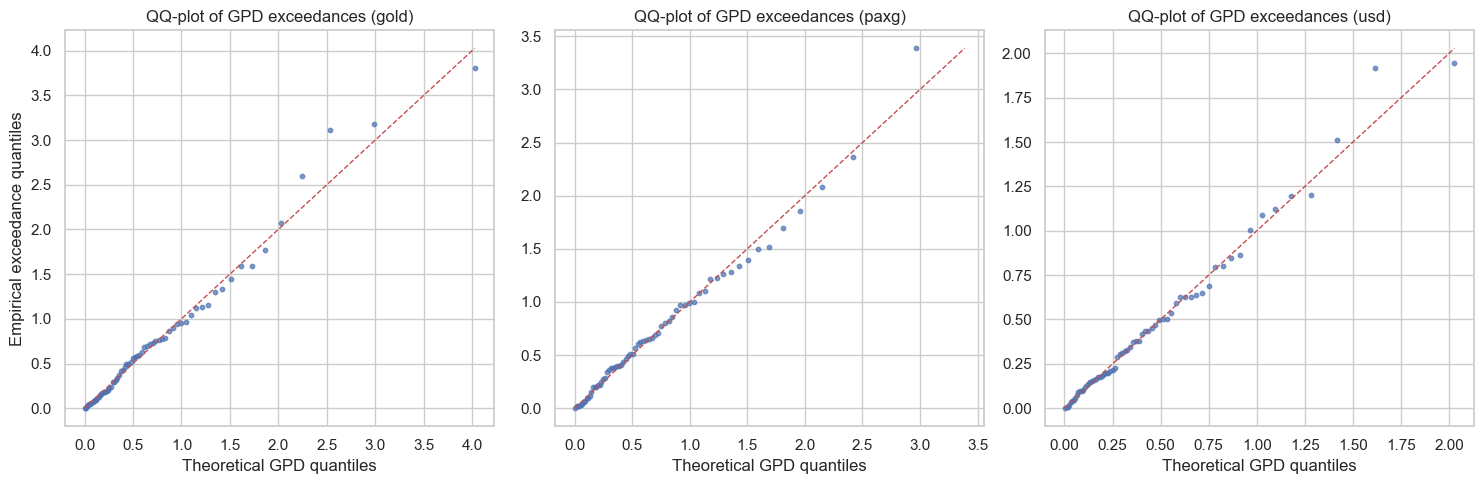

In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import genpareto

assets = ["gold", "paxg", "usd"]

fig, axes = plt.subplots(nrows=1, ncols=len(assets), figsize=(15, 5))

for ax, asset in zip(axes, assets):
    res = garch_results[asset]
    pars = evt_fits[asset]

    z = pd.Series(res.std_resid).dropna().to_numpy()
    y = -z
    u = pars["threshold_u"]
    excesses = np.sort(y[y > u] - u)

    p = (np.arange(1, len(excesses) + 1) - 0.5) / len(excesses)
    emp_q = excesses
    th_q = genpareto.ppf(p, c=pars["xi"], loc=0, scale=pars["beta"])

    # 2. Remplacer plt par ax pour cibler le bon sous-graphique
    ax.scatter(th_q, emp_q, s=10, alpha=0.7)
    
    # Calcul de la limite pour la ligne rouge de référence
    lim = max(np.nanmax(th_q), np.nanmax(emp_q))
    ax.plot([0, lim], [0, lim], "r--", lw=1)
    
    # 3. Ajouter l'étiquette X et le titre pour chaque graphique
    ax.set_xlabel("Theoretical GPD quantiles")
    ax.set_title(f"QQ-plot of GPD exceedances ({asset})")

# 4. Ajouter l'étiquette Y uniquement sur le graphique le plus à gauche
axes[0].set_ylabel("Empirical exceedance quantiles")

plt.tight_layout()
plt.show()

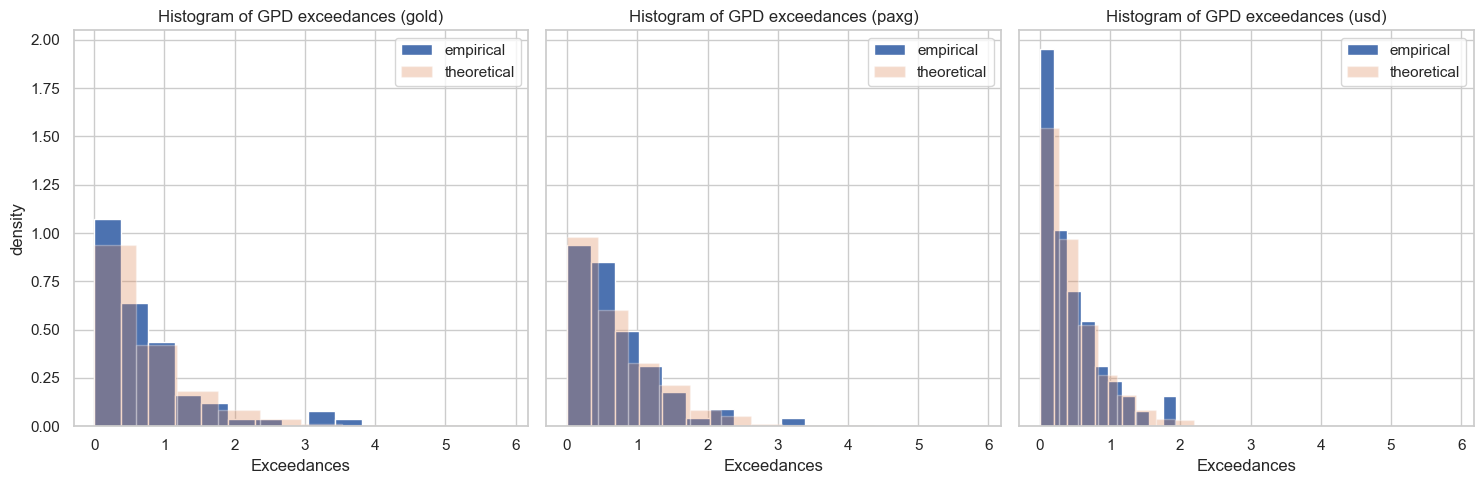

In [23]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import genpareto

assets = ["gold", "paxg", "usd"]

# 1. Créer une figure avec 1 ligne, 3 colonnes et un axe X partagé
# J'ai aussi élargi la figure (figsize) et ajouté sharey=True pour que 
# les échelles verticales soient identiques et faciles à comparer.
fig, axes = plt.subplots(nrows=1, ncols=len(assets), figsize=(15, 5), sharex=True, sharey=True)

for ax, asset in zip(axes, assets):
    res = garch_results[asset]
    pars = evt_fits[asset]

    z = pd.Series(res.std_resid).dropna().to_numpy()
    y = -z
    u = pars["threshold_u"]
    excesses = np.sort(y[y > u] - u)
    
    th_data = genpareto.rvs(c=pars["xi"], loc=0, scale=pars["beta"], size=1000)
    
    # Tracer sur l'axe spécifique
    ax.hist(excesses, label="empirical", density=True)
    ax.hist(th_data, label="theoretical", alpha=0.3, density=True)
    ax.legend()

    # Ajouter le titre et le label X pour chaque graphique
    ax.set_title(f"Histogram of GPD exceedances ({asset})")
    ax.set_xlabel("Exceedances")

# 2. Ajouter le label Y uniquement sur le premier graphique (tout à gauche)
axes[0].set_ylabel("density")

plt.tight_layout()
plt.show()

## EVT Conclusion

The EVT analysis confirms that tail risk is materially different across assets after GARCH standardization.

- **Physical gold** exhibits the heaviest left tail, indicating potentially severe extreme losses. This is consistent with the largest conditional risk measures in the sample.
- **PAXG** shows a milder tail profile, with lower extreme-loss estimates than physical gold.
- **USD index** has the least severe tail behavior , and the smallest extreme-risk metrics.

Across all assets, ES is consistently more negative than VaR, which is expected and supports internal consistency of the EVT layer.

- We can also notice that in the Q-Q quantile plot, there are some step-like platterns, which means the real data exhibit some highly similar loss magnitudes. It is due to the fact that the quantity of data is relatively small and perhaps some market microstructure effects—such as the clustering of limit orders around specific psychological support levels, which temporarily halts price drops at exact thresholds.

## Last steps before copula estimation:

1. Build aligned standardized residuals from fitted GARCH models.
2. Build semi-parametric marginal CDFs with EVT tails and empirical center.
3. Transform residuals to pseudo-observations $u_{i,t}\in(0,1)$ (PIT).

In [24]:
# 1) Aligned standardized residuals
z_series = {
    asset: pd.Series(res.std_resid).dropna().rename(asset)
    for asset, res in garch_results.items()
}
z_df = pd.concat(z_series.values(), axis=1, join="inner").dropna()

print(f"Aligned sample size for copula stage: {len(z_df)}")
display(z_df.head())

Aligned sample size for copula stage: 1310


,gold,paxg,usd
0,1.517157,0.422129,-0.061435
1,0.982885,0.078371,-0.579644
2,0.298891,-0.079603,0.979655
3,-0.928642,1.521008,0.998072
4,-0.394636,-0.346148,0.445377


In [25]:
# 2) Semi-parametric EVT marginals (two-sided tails)
def fit_evt_two_sided(z, tail_q=0.95):
    z = np.asarray(z, dtype=float)
    z_low = np.quantile(z, 1 - tail_q)
    z_high = np.quantile(z, tail_q)

    # Left tail via Y_L = -Z
    y_l = -z
    u_l = np.quantile(y_l, tail_q)
    exc_l = y_l[y_l > u_l] - u_l
    xi_l, _, beta_l = genpareto.fit(exc_l, floc=0)
    p_l = len(exc_l) / len(z)

    # Right tail via Y_U = Z
    y_u = z
    u_u = np.quantile(y_u, tail_q)
    exc_u = y_u[y_u > u_u] - u_u
    xi_u, _, beta_u = genpareto.fit(exc_u, floc=0)
    p_u = len(exc_u) / len(z)

    return {
        "z_low": float(z_low),
        "z_high": float(z_high),
        "left": {"u": float(u_l), "xi": float(xi_l), "beta": float(beta_l), "p": float(p_l)},
        "right": {"u": float(u_u), "xi": float(xi_u), "beta": float(beta_u), "p": float(p_u)},
        "z_sorted": np.sort(z),
    }

def empirical_cdf(z_sorted, x):
    # Mid-rank empirical CDF in [1/(2n), 1-1/(2n)]
    n = len(z_sorted)
    r = np.searchsorted(z_sorted, x, side="right")
    return (r - 0.5) / n

def gpd_survival(y, u, xi, beta):
    if y <= u:
        return 1.0
    t = 1.0 + xi * (y - u) / beta
    if t <= 0:
        return 0.0
    if abs(xi) < 1e-8:
        return np.exp(-(y - u) / beta)
    return t ** (-1.0 / xi)

def semiparametric_cdf(z_val, pars):
    z_low = pars["z_low"]
    z_high = pars["z_high"]
    left = pars["left"]
    right = pars["right"]

    if z_val <= z_low:
        y = -z_val
        # F_Z(z) = P(Z<=z) = P(Y_L>=y) ~ p_l * S_GPD(y-u_l)
        f = left["p"] * gpd_survival(y, left["u"], left["xi"], left["beta"])
    elif z_val >= z_high:
        y = z_val
        # 1 - F_Z(z) = P(Z>z) ~ p_u * S_GPD(y-u_u)
        f = 1.0 - right["p"] * gpd_survival(y, right["u"], right["xi"], right["beta"])
    else:
        f = empirical_cdf(pars["z_sorted"], z_val)

    return float(np.clip(f, 1e-6, 1 - 1e-6))

evt_marginals = {asset: fit_evt_two_sided(z_df[asset].to_numpy(), tail_q=0.95) for asset in z_df.columns}
print("Marginals fitted for:", list(evt_marginals.keys()))

Marginals fitted for: ['gold', 'paxg', 'usd']


In [26]:
# 3) PIT transform: residuals -> pseudo-observations in (0,1)
u_df = pd.DataFrame({
    asset: [semiparametric_cdf(v, evt_marginals[asset]) for v in z_df[asset].to_numpy()]
    for asset in z_df.columns
}, index=z_df.index)

pre_copula_package = {
    "z_df": z_df,
    "u_df": u_df,
    "evt_marginals": evt_marginals,
}

display(u_df.head())
print("- z_df shape:", z_df.shape)
print("- u_df shape:", u_df.shape)

,gold,paxg,usd
0,0.941603,0.688931,0.469847
1,0.867557,0.527863,0.267557
2,0.613359,0.453053,0.846947
3,0.138550,0.937786,0.849237
4,0.286641,0.324809,0.690458


- z_df shape: (1310, 3)
- u_df shape: (1310, 3)


Voir https://arxiv.org/pdf/2407.15766 page 19

Si on fait la méthode classique (celle du cours): Empirical cumulative distribution function

In [27]:
from scipy.stats import rankdata

In [28]:
def ecdf_transform(colonne):
    col_propre = colonne.dropna()
    N = len(col_propre)
    return rankdata(col_propre) / (N + 1)

# 2. La magie de Pandas : On applique cette fonction à toutes les colonnes en même temps !
u_df = z_df.apply(ecdf_transform)

# 3. Vérification de rigueur
print("Aperçu des marges uniformes U(0,1) :")
print(u_df.head())

print("\nVérification des bornes (doivent être >0 et <1) :")
print("Minimaux :\n", u_df.min())
print("Maximaux :\n", u_df.max())

Aperçu des marges uniformes U(0,1) :
       gold      paxg       usd
0  0.941266  0.688787  0.469870
1  0.867277  0.527841  0.267735
2  0.613272  0.453089  0.846682
3  0.138825  0.937452  0.848970
4  0.286804  0.324943  0.690313

Vérification des bornes (doivent être >0 et <1) :
Minimaux :
 gold    0.000763
paxg    0.000763
usd     0.000763
dtype: float64
Maximaux :
 gold    0.999237
paxg    0.999237
usd     0.999237
dtype: float64


--- GÉNÉRATION DES SIMULATIONS THÉORIQUES ---


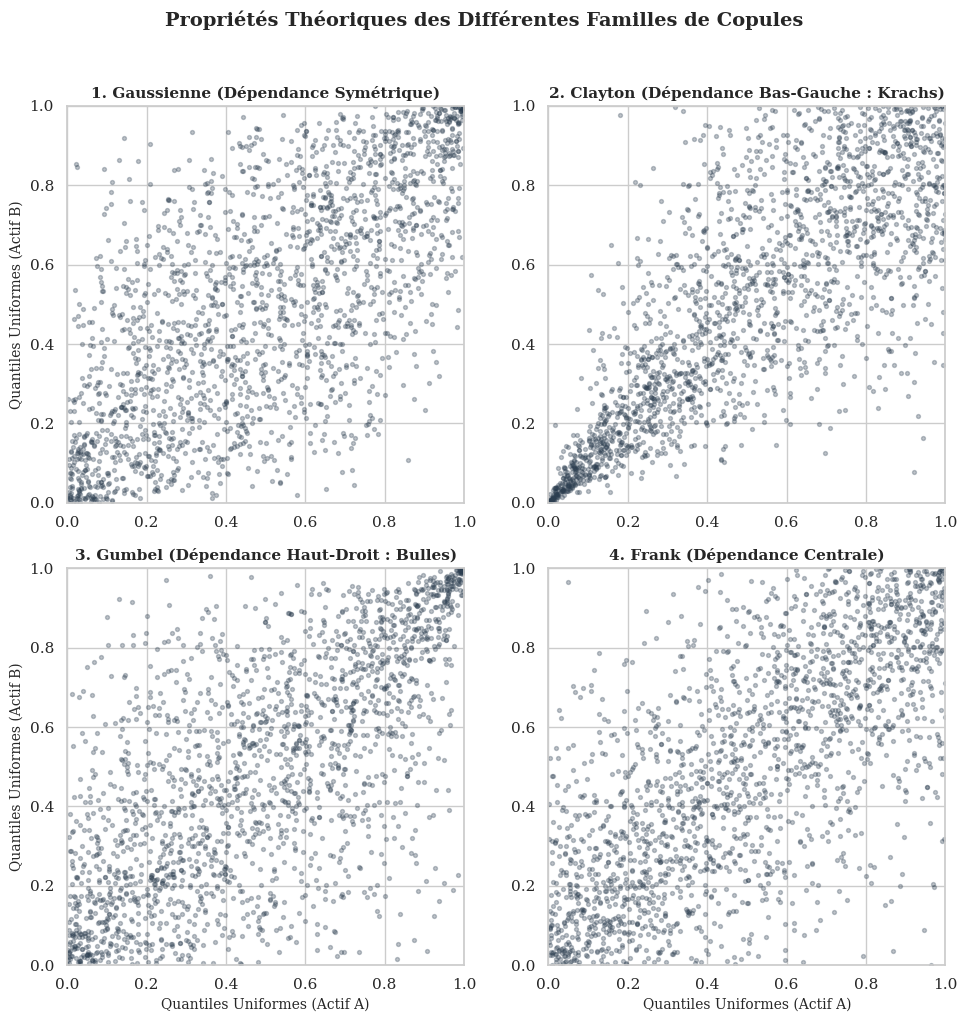

In [29]:
# First of all, we look at the theorectical model to feel a bit the different properties/topologies of differents copulas

from statsmodels.distributions.copula.api import (
    GaussianCopula, ClaytonCopula, FrankCopula, GumbelCopula
)

# --- Esthétique pour le mémoire ---
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'serif'

# 1. Paramètres de simulation
n_samples = 2000 # On génère beaucoup de points pour bien voir la forme (densité)

# On choisit des paramètres théoriques pour avoir une dépendance globale similaire (ex: Tau de Kendall ~0.5)
# L'objectif est de montrer la forme pure de la dépendance
copules_theoriques = {
    "1. Gaussienne (Dépendance Symétrique)": GaussianCopula(corr=0.7),
    "2. Clayton (Dépendance Bas-Gauche : Krachs)": ClaytonCopula(theta=3.0),
    "3. Gumbel (Dépendance Haut-Droit : Bulles)": GumbelCopula(theta=2.0),
    "4. Frank (Dépendance Centrale)": FrankCopula(theta=6.0)
}

# 2. Création de la figure (Grille 2x2)
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten() # Pour itérer facilement sur les 4 graphiques

print("--- GÉNÉRATION DES SIMULATIONS THÉORIQUES ---")

# 3. Boucle de simulation et de tracé
for i, (titre, copule) in enumerate(copules_theoriques.items()):
    ax = axes[i]
    
    # On simule 2000 scénarios tirés de la loi de cette copule spécifique
    simulations = copule.rvs(nobs=n_samples, random_state=42)
    
    # Extraction des coordonnées U et V
    u = simulations[:, 0]
    v = simulations[:, 1]
    
    # Le nuage de points
    ax.scatter(u, v, alpha=0.3, s=8, color='#2c3e50')
    
    # Formatage strict (Domaine des copules = Carré [0,1])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal', 'box')
    
    # Textes
    ax.set_title(titre, fontweight='bold', fontsize=11)
    if i >= 2: ax.set_xlabel("Quantiles Uniformes (Actif A)", fontsize=10)
    if i % 2 == 0: ax.set_ylabel("Quantiles Uniformes (Actif B)", fontsize=10)

plt.suptitle("Propriétés Théoriques des Différentes Familles de Copules", 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

A little visualization of the empirical data before all.

--- GÉNÉRATION DES GRAPHIQUES DE DÉPENDANCE ---


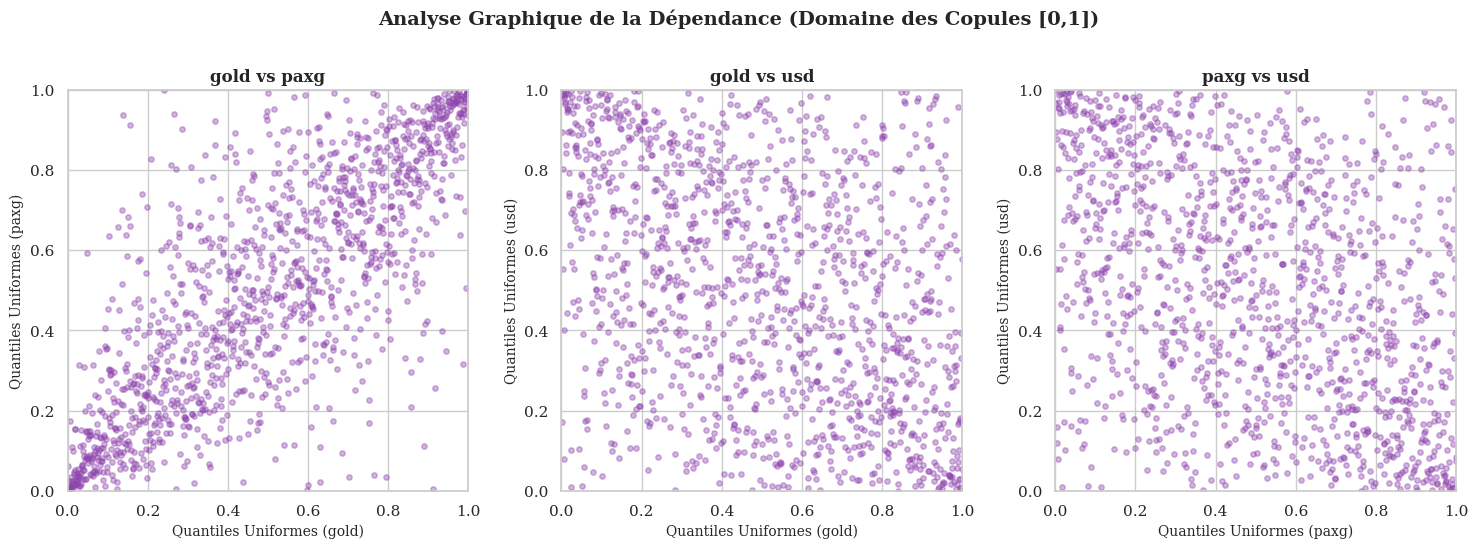

In [30]:

import itertools

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'serif'

# 1. On récupère toutes les paires possibles depuis votre DataFrame u_df
colonnes = u_df.columns
paires = list(itertools.combinations(colonnes, 2))

# 2. Création de la figure (1 ligne, 3 colonnes)
# figsize=(15, 5) permet d'avoir un format panoramique parfait pour la largeur d'une page Word
fig, axes = plt.subplots(1, len(paires), figsize=(15, 5))

print("--- GÉNÉRATION DES GRAPHIQUES DE DÉPENDANCE ---")

# 3. Boucle pour dessiner chaque graphique
for i, (actif1, actif2) in enumerate(paires):
    ax = axes[i]
    
    # Le nuage de points
    # alpha=0.4 rend les points transparents pour bien voir les zones de forte densité (les amas)
    # s=15 règle la taille des points
    ax.scatter(u_df[actif1], u_df[actif2], alpha=0.4, s=15, color='#8e44ad')
    
    # On force les axes de 0 à 1 (puisque ce sont des probabilités)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    
    # On force le graphique à être un carré parfait (très important pour les copules !)
    ax.set_aspect('equal', 'box')
    
    # Titres et labels
    ax.set_title(f"{actif1} vs {actif2}", fontweight='bold', fontsize=12)
    ax.set_xlabel(f"Quantiles Uniformes ({actif1})", fontsize=10)
    ax.set_ylabel(f"Quantiles Uniformes ({actif2})", fontsize=10)

plt.suptitle("Analyse Graphique de la Dépendance (Domaine des Copules [0,1])", fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

We try to fit different copula on these 3 pairs, and see which one modelize the dependance best.

In [31]:
import numpy as np
import pandas as pd
import itertools
import warnings
from statsmodels.distributions.copula.api import (
    GaussianCopula, ClaytonCopula, FrankCopula, GumbelCopula
)

warnings.filterwarnings("ignore")

# 1. Préparation des données
u_df_propre = u_df.clip(lower=1e-5, upper=1 - 1e-5)
paires = list(itertools.combinations(u_df_propre.columns, 2))

copules_a_tester = {
    "Gaussienne (Symétrique)": GaussianCopula(),
    "Clayton (Krachs / Baisse)": ClaytonCopula(),
    "Gumbel (Bulles / Hausse)": GumbelCopula(),
    "Frank (Centre)": FrankCopula()
}

resultats_globaux = []

print("=== DÉBUT DE LA COMPÉTITION DES COPULES (AVEC ROTATIONS) ===\n")

for actif1, actif2 in paires:
    print(f"--- Analyse de la paire : {actif1} vs {actif2} ---")
    
    donnees_uniformes_base = u_df_propre[[actif1, actif2]].dropna()
    resultats_paire = []
    
    # On détecte si le Dollar est dans la paire (adaptez le nom selon votre colonne exacte)
    has_usd = ('Dollar' in actif1) or ('Dollar' in actif2)
    
    # Si USD est présent, on teste la version normale (0°), 90° et 270°
    rotations_a_tester = [0, 90, 270] if has_usd else [0]
    
    for rot in rotations_a_tester:
        # Transformation des probabilités selon l'angle
        if rot == 0:
            donnees_fit = donnees_uniformes_base.copy()
            suffixe = ""
        elif rot == 90:
            # Rotation 90° : On inverse l'actif 1 (u -> 1-u)
            donnees_fit = np.column_stack((1 - donnees_uniformes_base[:, 0], donnees_uniformes_base[:, 1]))
            suffixe = " (Rotated 90°)"
        elif rot == 270:
            # Rotation 270° : On inverse l'actif 2 (v -> 1-v)
            donnees_fit = np.column_stack((donnees_uniformes_base[:, 0], 1 - donnees_uniformes_base[:, 1]))
            suffixe = " (Rotated 270°)"

        for nom_base, copule in copules_a_tester.items():
            nom = nom_base + suffixe
            
            # OPTIMISATION : La Gaussienne et Frank gèrent déjà les corrélations négatives naturellement. 
            # Inutile de les rotater, on ne tourne que Clayton et Gumbel !
            if rot != 0 and isinstance(copule, (GaussianCopula, FrankCopula)):
                continue

        
            if isinstance(copule, GaussianCopula):
                param_estime = copule.fit_corr_param(donnees_fit)
                pdf_valeurs = copule.pdf(donnees_fit)
            else:
               
                param_estime = copule.fit_corr_param(donnees_fit)
                pdf_valeurs = copule.pdf(donnees_fit, param_estime)
            
            # Sécurité mathématique
            pdf_valeurs = np.clip(pdf_valeurs, 1e-10, np.inf) 
            log_vraisemblance = np.sum(np.log(pdf_valeurs))
            
            # Calcul de l'AIC
            aic = 2 * 1 - 2 * log_vraisemblance
            
            resultats_paire.append({
                "Paire": f"{actif1}-{actif2}",
                "Copule": nom,
                "Paramètre": param_estime,
                "AIC": aic
            })
            
       
                
    # Vérification anti-crash
    if len(resultats_paire) == 0:
        print(f"  -> ERREUR : Aucune copule n'a marché pour {actif1}-{actif2}\n")
        continue

    # Classement de la paire
    df_paire = pd.DataFrame(resultats_paire)
    df_paire = df_paire.sort_values(by="AIC").reset_index(drop=True)
    
    # Affichage du Top 3 pour voir le combat
    print(df_paire.head(3).to_string(index=False))
    print(f"-> GAGNANTE POUR {actif1}-{actif2} : {df_paire.iloc[0]['Copule']}\n")
    
    resultats_globaux.append(df_paire.iloc[0].to_dict())

print("=== RÉSUMÉ FINAL DES COPULES GAGNANTES ===")
df_final = pd.DataFrame(resultats_globaux)
print(df_final[['Paire', 'Copule', 'Paramètre', 'AIC']].to_string(index=False))

=== DÉBUT DE LA COMPÉTITION DES COPULES (AVEC ROTATIONS) ===

--- Analyse de la paire : gold vs paxg ---
    Paire                    Copule  Paramètre          AIC
gold-paxg            Frank (Centre)   7.798091 -1236.663457
gold-paxg  Gumbel (Bulles / Hausse)   2.469242 -1233.367076
gold-paxg Clayton (Krachs / Baisse)   2.938485  -991.859356
-> GAGNANTE POUR gold-paxg : Frank (Centre)

--- Analyse de la paire : gold vs usd ---
   Paire                   Copule  Paramètre         AIC
gold-usd           Frank (Centre)  -2.463131 -200.814774
gold-usd  Gaussienne (Symétrique)  -0.395143    2.000000
gold-usd Gumbel (Bulles / Hausse)   0.794527  254.003147
-> GAGNANTE POUR gold-usd : Frank (Centre)

--- Analyse de la paire : paxg vs usd ---
   Paire                   Copule  Paramètre         AIC
paxg-usd           Frank (Centre)  -2.594524 -221.157696
paxg-usd  Gaussienne (Symétrique)  -0.412717    2.000000
paxg-usd Gumbel (Bulles / Hausse)   0.786881  308.113937
-> GAGNANTE POUR paxg-usd 

In [47]:
# we take the best copula for gold-usd
param_gold_usd = FrankCopula().fit_corr_param(u_df_propre[['gold', 'usd']].dropna().copy())
param_gold_usd

np.float64(-2.4631307681856955)

To show that copula may be better, we compare with linear correlation (they are more rough)

--- CALCUL DES MATRICES DE CORRÉLATION ---


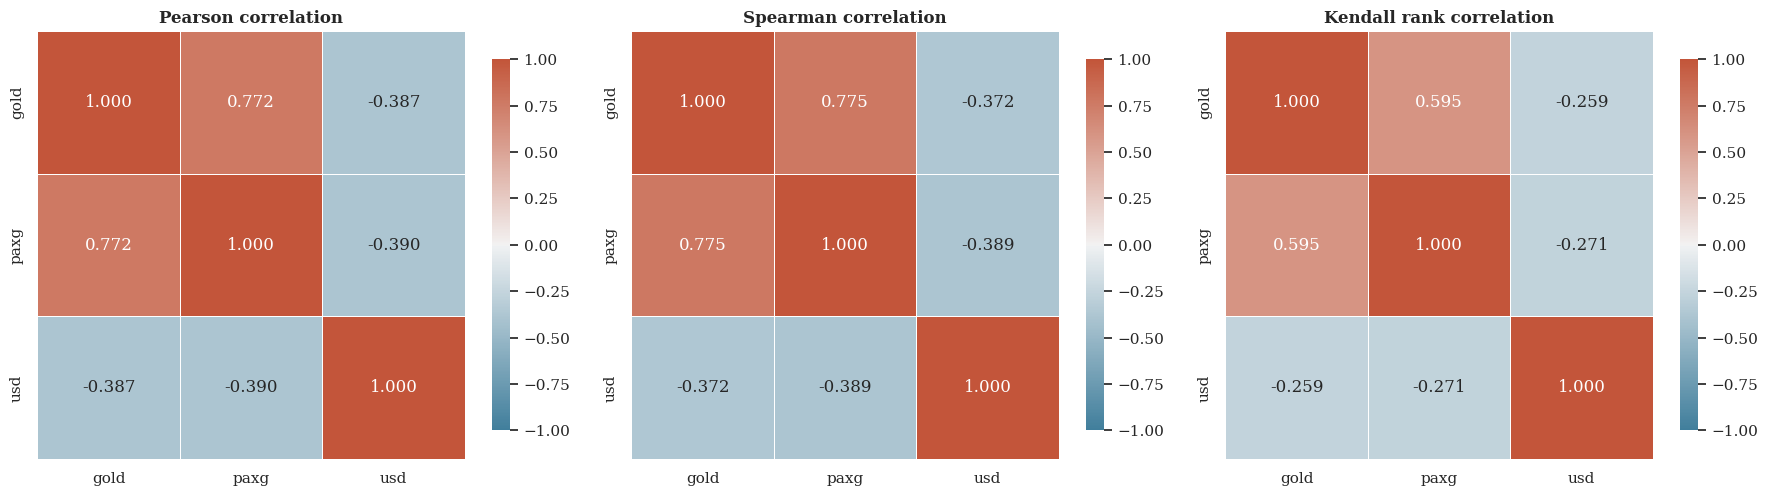

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Esthétique pour le mémoire ---
sns.set_theme(style="white")
plt.rcParams['font.family'] = 'serif'

# 1. Vos données : On utilise z_df (les résidus standardisés de vos GARCH)
# C'est ici qu'on mesure la corrélation des chocs purs.
# Assurez-vous d'avoir enlevé les NaN
donnees_chocs = z_df.dropna()

print("--- CALCUL DES MATRICES DE CORRÉLATION ---")

# 2. Calcul des 3 types de corrélation
corr_pearson = donnees_chocs.corr(method='pearson')   # La classique (Linéaire)
corr_spearman = donnees_chocs.corr(method='spearman') # Basée sur les Rangs
corr_kendall = donnees_chocs.corr(method='kendall')   # Basée sur les Paires Concordantes

# 3. La Visualisation (3 Heatmaps côte à côte)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Palette de couleurs (rouge pour positif, bleu pour négatif)
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# A. Heatmap Pearson
sns.heatmap(corr_pearson, annot=True, fmt=".3f", cmap=cmap, vmin=-1, vmax=1, 
            square=True, linewidths=.5, ax=axes[0], cbar_kws={"shrink": .8})
axes[0].set_title("Pearson correlation", fontweight='bold')

# B. Heatmap Spearman
sns.heatmap(corr_spearman, annot=True, fmt=".3f", cmap=cmap, vmin=-1, vmax=1, 
            square=True, linewidths=.5, ax=axes[1], cbar_kws={"shrink": .8})
axes[1].set_title("Spearman correlation", fontweight='bold')

# C. Heatmap Kendall
sns.heatmap(corr_kendall, annot=True, fmt=".3f", cmap=cmap, vmin=-1, vmax=1, 
            square=True, linewidths=.5, ax=axes[2], cbar_kws={"shrink": .8})
axes[2].set_title("Kendall rank correlation", fontweight='bold')

plt.tight_layout()
plt.show()

[*********************100%***********************]  2 of 2 completed
[*********************100%***********************]  2 of 2 completed


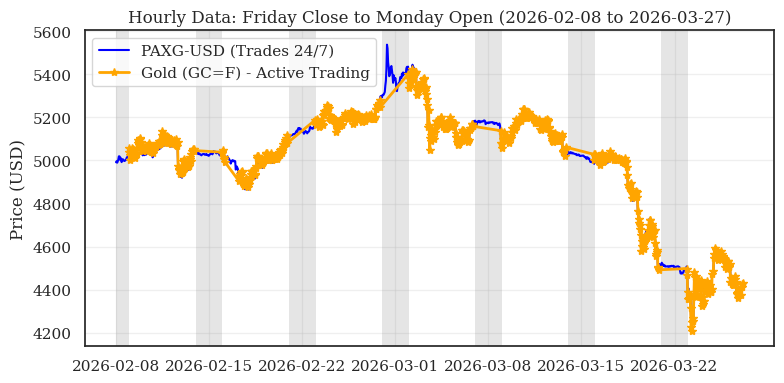

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

tickers = ["GLD", "PAXG-USD"]
start_date = "2020-03-20"
end_date = "2026-03-20"

# 1. Download Daily Data for the Macro Overview
df_daily = yf.download(tickers, start=start_date, end=end_date)['Close']
df_daily = df_daily.resample('D').asfreq()

# 2. Download Hourly Data for the Zoomed-In Weekend View
# Note: yfinance only allows 1h data for the last 730 days, so we pick a recent month
zoom_start = '2026-02-08'
zoom_end = '2026-03-27'
df_hourly = yf.download(tickers, start=zoom_start, end=zoom_end, interval="1h")['Close']

# ==========================================
# Subplot 2: Zoomed-in View (Hourly)
# ==========================================
# Plot PAXG-USD (Continuous hourly trading)
plt.figure(figsize=(8,4))
plt.plot(df_hourly.index, df_hourly['PAXG-USD'], label='PAXG-USD (Trades 24/7)', color='blue')

# Plot GC=F (Trading hours only). We drop NAs so it doesn't connect the weekend gap natively.
gc_trading_hours = df_hourly['GC=F'].dropna()
plt.plot(gc_trading_hours.index, gc_trading_hours,marker = "*", label='Gold (GC=F) - Active Trading', color='orange', linewidth=2)
# Highlight the weekends using the hourly index
# We group by day to find Saturdays and Sundays and shade them
unique_days = pd.Series(df_hourly.index.date).unique()
for day in unique_days:
    # Convert back to timestamp to check weekday (5=Sat, 6=Sun)
    ts = pd.Timestamp(day)
    if ts.dayofweek >= 5: 
        start_shade = ts
        end_shade = ts + pd.Timedelta(days=1)
        plt.axvspan(start_shade, end_shade, color='gray', alpha=0.2, lw=0)

plt.title(f'Hourly Data: Friday Close to Monday Open ({zoom_start} to {zoom_end})')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

We verify that even if PAXG is traded 24/7 while gold is traded only on weekdays, the price of PAXG will soon go to the same level at the beginning of Monday's trading.

# TODO: calculate TDC 

# Application to the real world

We then try to show that with GARCH-EVT-Copula, we can bette estimate the real world risk. Like in the paper https://arxiv.org/pdf/2407.15766, we simulate 5000 scenarios for a fix portefolio (for example 30% gold, 70% usd) for the last year (unseen data, not included in model fitting), and we get the estimated worst loss with different dependence models, for example, the best-fitted copula and 2 gaussian model with a certain covariance. And then we may expect to say that the copula is closer to the ground truth.

In [36]:

tickers = ["GC=F", "PAXG-USD", "DX-Y.NYB"]
test_start_date = "2025-03-21"
test_end_date = "2026-03-20"

test_raw_data = yf.download(tickers, start=test_start_date, end=test_end_date)['Close']

# Clean and Align the Data (The "Inner Join" logic)
# Traditional markets are closed on weekends/holidays, resulting in NaNs.
# Using .dropna() automatically drops the crypto weekend data, aligning everything perfectly.
test_aligned_data = test_raw_data.dropna()
test_aligned_data.columns = ['US Dollar Index', 'Physical Gold', 'PAX Gold']

# Calculate Daily Log-Returns
# Formula: ln(P_t / P_{t-1})
# !!!! attention, we *100 to scale the data

test_log_returns = np.log(test_aligned_data / test_aligned_data.shift(1)).dropna()
test_gold_array = test_log_returns['Physical Gold'].values*100
test_paxg_array = test_log_returns['PAX Gold'].values*100
test_usd_array = test_log_returns['US Dollar Index'].values*100
print(f"Shape of the test NumPy arrays: {test_gold_array.shape} days of trading.")


[*********************100%***********************]  3 of 3 completed

Shape of the test NumPy arrays: (249,) days of trading.


In [43]:

print("--- PORTFOLIO OPTIMIZATION (Markowitz Portfolio Theory) ---")

# 1. Calculate the variance-covariance matrix
# np.cov returns a 2x2 matrix. 
# Diagonal = Variances / Off-diagonal = Covariance
cov_matrix = np.cov(gold_array, usd_array)

var_gold = cov_matrix[0, 0]      # Variance of Gold
var_usd = cov_matrix[1, 1]      # Variance of usd
cov_gold_usd = cov_matrix[0, 1] # Covariance between the two assets

# 2. Apply the Global Minimum Variance (GMV) formula
optimal_weight_gold = (var_usd - cov_gold_usd) / (var_gold + var_usd - 2 * cov_gold_usd)

# Security check: ensure weights remain between 0 and 1 (no short selling constraint)
optimal_weight_gold = np.clip(optimal_weight_gold, 0, 1)
optimal_weight_usd = 1 - optimal_weight_gold

# 3. Display the results
print("\n[ OPTIMAL WEIGHTS RESULTS (Global Minimum Variance Portfolio) ]")
print(f"-> Optimal allocation in Gold : {optimal_weight_gold * 100:.2f} %")
print(f"-> Optimal allocation in usd : {optimal_weight_usd * 100:.2f} %")

--- PORTFOLIO OPTIMIZATION (Markowitz Portfolio Theory) ---

[ OPTIMAL WEIGHTS RESULTS (Global Minimum Variance Portfolio) ]
-> Optimal allocation in Gold : 23.25 %
-> Optimal allocation in usd : 76.75 %


In [ ]:


model_gold_2025 = arch_model(test_gold_array, vol='Garch', p=1, q=1, dist='normal')
gold_garch_predict = model_gold_2025.fix(gold_garch_results.params)
vol_gold_pred = gold_garch_predict.conditional_volatility
std_res_gold_pred = gold_garch_predict.std_resid


model_usd_2025 = arch_model(test_usd_array, vol='Garch', p=1, q=1, dist='normal')
usd_garch_predict = model_usd_2025.fix(usd_garch_results.params)
vol_usd_pred = usd_garch_predict.conditional_volatility
std_res_usd_pred = usd_garch_predict.std_resid



In [ ]:

test_day = len(test_gold_array)
n_simulations = 5000
var_95_portefolio = []

print("--- 1. DYNAMIC VaR SIMULATION (MONTE CARLO) ---")

for t in range(test_day):
    # 1. Copula generates joint probabilities (5000 scenarios)
    # Using FrankCopula with the parameter you previously estimated
    if param_gold_usd < 0:
        # If theta is negative, we simulate with POSITIVE theta to avoid the Python crash...
        sims_u = FrankCopula(theta=abs(param_gold_usd)).rvs(nobs=n_simulations, random_state=t)
        # ...and we manually invert the second asset (1 - v) to restore the NEGATIVE correlation!
        sims_u[:, 1] = 1 - sims_u[:, 1]
    else:
        # If theta is positive, everything works normally
        sims_u = FrankCopula(theta=param_gold_usd).rvs(nobs=n_simulations, random_state=t)
    
    # 2. Inverse Transformation: Probabilities -> Standardized Shocks (Z)
    z_gold_sim = np.quantile(z_df['gold'], sims_u[:, 0])
    z_usd_sim = np.quantile(z_df['usd'], sims_u[:, 1])
    
    # 3. Reintroduce the predicted GARCH volatility for day 't'
    return_gold_sim = z_gold_sim * vol_gold_pred[t]
    return_usd_sim = z_usd_sim * vol_usd_pred[t]
    
    # 4. Create the simulated portfolio and extract the 95% VaR (5th percentile)
    portfolio_sim = (optimal_weight_gold * return_gold_sim) + (optimal_weight_usd * return_usd_sim)
    var_95_day_t = np.percentile(portfolio_sim, 5) 
    
    var_95_portefolio.append(var_95_day_t)

var_95_portefeuille = np.array(var_95_portefolio)
print("Simulation completed without crashes!")

--- 1. DYNAMIC VaR SIMULATION (MONTE CARLO) ---
Simulation completed without crashes!


--- 2. CALCULATION OF TRUE PORTFOLIO RETURNS ---
--- 3. BACKTESTING (VIOLATION TEST) ---
Trading days tested: 249
Expected violations (5% target): 12.5
Actual violations of the model: 11
Actual failure rate: 4.42%


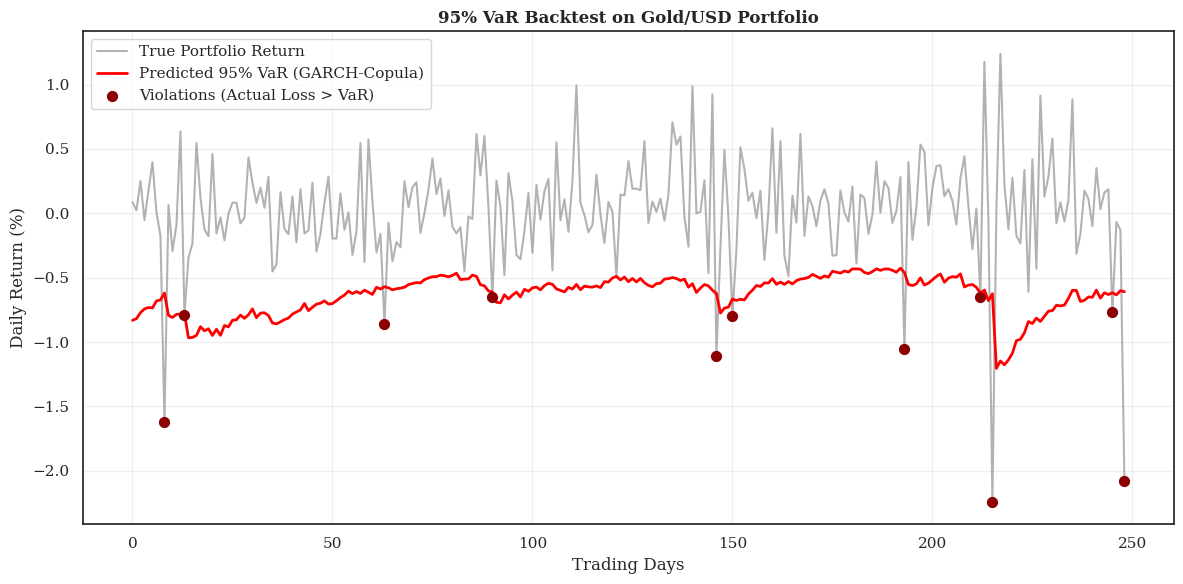

In [55]:


# Assuming true_returns_gold and true_returns_usd are your actual out-of-sample data
# and weight_gold, weight_usd are the optimal weights calculated previously.

print("--- 2. CALCULATION OF TRUE PORTFOLIO RETURNS ---")
true_returns_portfolio = (optimal_weight_gold * test_gold_array) + (optimal_weight_usd * test_usd_array)

print("--- 3. BACKTESTING (VIOLATION TEST) ---")
# A violation occurs when the actual return is lower (worse loss) than the predicted VaR
violations = true_returns_portfolio < var_95_portefolio
num_violations = np.sum(violations)
actual_failure_rate = num_violations / test_day
expected_violations = test_day * 0.05

print(f"Trading days tested: {test_day}")
print(f"Expected violations (5% target): {expected_violations:.1f}")
print(f"Actual violations of the model: {num_violations}")
print(f"Actual failure rate: {actual_failure_rate * 100:.2f}%")

# --- 4. BACKTEST PLOT FOR THE THESIS ---
plt.figure(figsize=(12, 6))

# Ensure data is treated as arrays to prevent Pandas index mismatches in Matplotlib
true_returns_array = true_returns_portfolio.values if isinstance(true_returns_portfolio, pd.Series) else true_returns_portfolio

# Plot the true portfolio returns
plt.plot(true_returns_array, label='True Portfolio Return', color='gray', alpha=0.6)

# Plot the red danger line (Predicted VaR)
plt.plot(var_95_portefolio, label='Predicted 95% VaR (GARCH-Copula)', color='red', linewidth=2)

# Add red dots where the model failed (Violations)
indices_violations = np.where(violations)[0]
plt.scatter(indices_violations, 
            true_returns_array[indices_violations], 
            color='darkred', s=50, zorder=5, label='Violations (Actual Loss > VaR)')

plt.title("95% VaR Backtest on Gold/USD Portfolio", fontweight='bold')
plt.xlabel("Trading Days")
plt.ylabel("Daily Return (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Historical Linear Correlation (Pearson): -0.3868
--- 1. RUNNING DYNAMIC VaR SIMULATIONS (COPULA VS LINEAR) ---
--- 2. BACKTESTING RESULTS ---
Target Violations (5%): 12.5
-> Linear Model Violations : 12 (Failure rate: 4.82%)
-> Copula Model Violations : 11 (Failure rate: 4.42%)


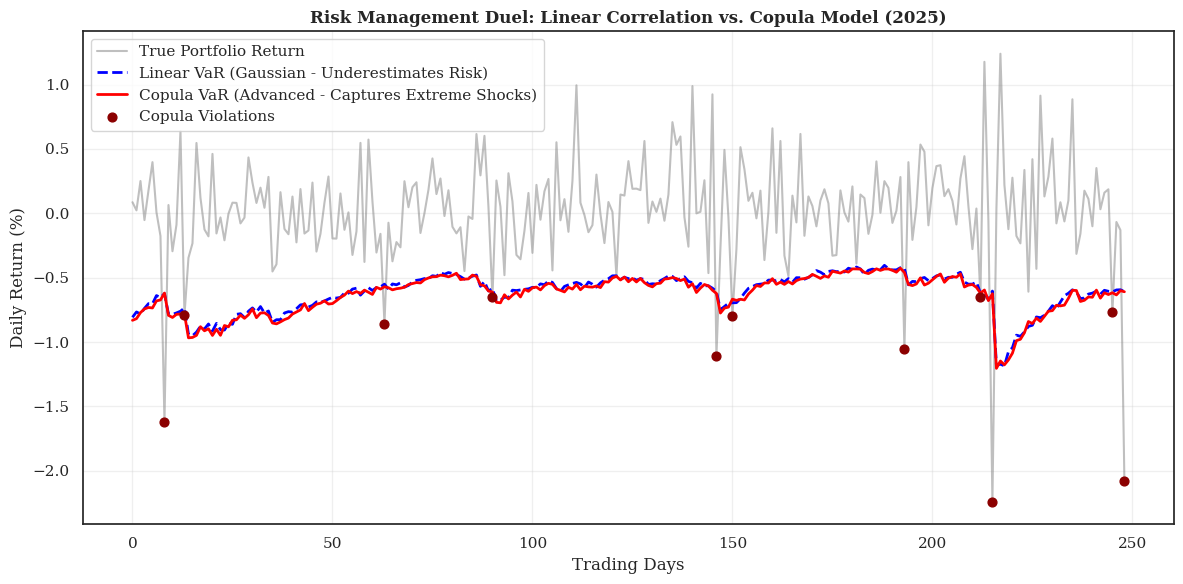

In [59]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import pearsonr
from statsmodels.distributions.copula.api import GaussianCopula, FrankCopula

# --- 0. SETUP: ESTIMATING THE LINEAR CORRELATION ---
# We calculate the simple linear correlation (Pearson) from your historical training data
linear_corr, _ = pearsonr(z_df['gold'], z_df['usd'])
print(f"Historical Linear Correlation (Pearson): {linear_corr:.4f}")

n_simulations = 5000
var_95_copula = []
var_95_linear = []

print("--- 1. RUNNING DYNAMIC VaR SIMULATIONS (COPULA VS LINEAR) ---")

for t in range(test_day):
    # ==========================================
    # MODEL A: ADVANCED COPULA (Frank/Clayton/etc.)
    # ==========================================
    if param_gold_usd < 0:
        sims_u_copula = FrankCopula(theta=abs(param_gold_usd)).rvs(nobs=n_simulations, random_state=t)
        sims_u_copula[:, 1] = 1 - sims_u_copula[:, 1]
    else:
        sims_u_copula = FrankCopula(theta=param_gold_usd).rvs(nobs=n_simulations, random_state=t)
        
    z_gold_copula = np.quantile(z_df['gold'], sims_u_copula[:, 0])
    z_usd_copula = np.quantile(z_df['usd'], sims_u_copula[:, 1])
    
    ret_gold_copula = z_gold_copula * vol_gold_pred[t]
    ret_usd_copula = z_usd_copula * vol_usd_pred[t]
    
    port_copula = (optimal_weight_gold * ret_gold_copula) + (optimal_weight_usd * ret_usd_copula)
    var_95_copula.append(np.percentile(port_copula, 5))
    
    # ==========================================
    # MODEL B: SIMPLE LINEAR CORRELATION (Gaussian Copula)
    # ==========================================
    # The Gaussian Copula perfectly replicates standard linear correlation
    sims_u_linear = GaussianCopula(corr=linear_corr).rvs(nobs=n_simulations, random_state=t)
    
    z_gold_linear = np.quantile(z_df['gold'], sims_u_linear[:, 0])
    z_usd_linear = np.quantile(z_df['usd'], sims_u_linear[:, 1])
    
    ret_gold_linear = z_gold_linear * vol_gold_pred[t]
    ret_usd_linear = z_usd_linear * vol_usd_pred[t]
    
    port_linear = (optimal_weight_gold * ret_gold_linear) + (optimal_weight_usd * ret_usd_linear)
    var_95_linear.append(np.percentile(port_linear, 5))

# Convert to arrays
var_95_copula = np.array(var_95_copula)
var_95_linear = np.array(var_95_linear)

print("--- 2. BACKTESTING RESULTS ---")
# Calculate true portfolio returns
true_returns_array = (optimal_weight_gold * test_gold_array) + (optimal_weight_usd * test_usd_array)
if isinstance(true_returns_array, pd.Series):
    true_returns_array = true_returns_array.values

# Count violations
violations_copula = np.sum(true_returns_array < var_95_copula)
violations_linear = np.sum(true_returns_array < var_95_linear)

print(f"Target Violations (5%): {test_day * 0.05:.1f}")
print(f"-> Linear Model Violations : {violations_linear} (Failure rate: {violations_linear/test_day*100:.2f}%)")
print(f"-> Copula Model Violations : {violations_copula} (Failure rate: {violations_copula/test_day*100:.2f}%)")

# --- 3. THE FINAL PLOT FOR YOUR THESIS ---
plt.figure(figsize=(12, 6))

# True returns
plt.plot(true_returns_array, label='True Portfolio Return', color='gray', alpha=0.5)

# The two competing VaR lines
plt.plot(var_95_linear, label='Linear VaR (Gaussian - Underestimates Risk)', color='blue', linestyle='--', linewidth=2)
plt.plot(var_95_copula, label='Copula VaR (Advanced - Captures Extreme Shocks)', color='red', linewidth=2)

# Mark the violations for the Copula model
indices_violations = np.where(true_returns_array < var_95_copula)[0]
plt.scatter(indices_violations, true_returns_array[indices_violations], 
            color='darkred', s=40, zorder=5, label='Copula Violations')

plt.title("Risk Management Duel: Linear Correlation vs. Copula Model (2025)", fontweight='bold')
plt.xlabel("Trading Days")
plt.ylabel("Daily Return (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Historical Linear Correlation (Pearson): -0.3868

--- 1. RUNNING MULTI-LEVEL DYNAMIC VaR SIMULATIONS ---
--- 2. BACKTESTING RESULTS (KUPIEC TEST METRICS) ---

[ VaR at 1% Level (99.0% Confidence) ]
Target Violations Allowed : 2.5
-> Linear Model Violations: 6 (Actual Rate: 2.41%)
-> Copula Model Violations: 6 (Actual Rate: 2.41%)

[ VaR at 2.5% Level (97.5% Confidence) ]
Target Violations Allowed : 6.2
-> Linear Model Violations: 7 (Actual Rate: 2.81%)
-> Copula Model Violations: 6 (Actual Rate: 2.41%)

[ VaR at 5% Level (95.0% Confidence) ]
Target Violations Allowed : 12.5
-> Linear Model Violations: 12 (Actual Rate: 4.82%)
-> Copula Model Violations: 11 (Actual Rate: 4.42%)


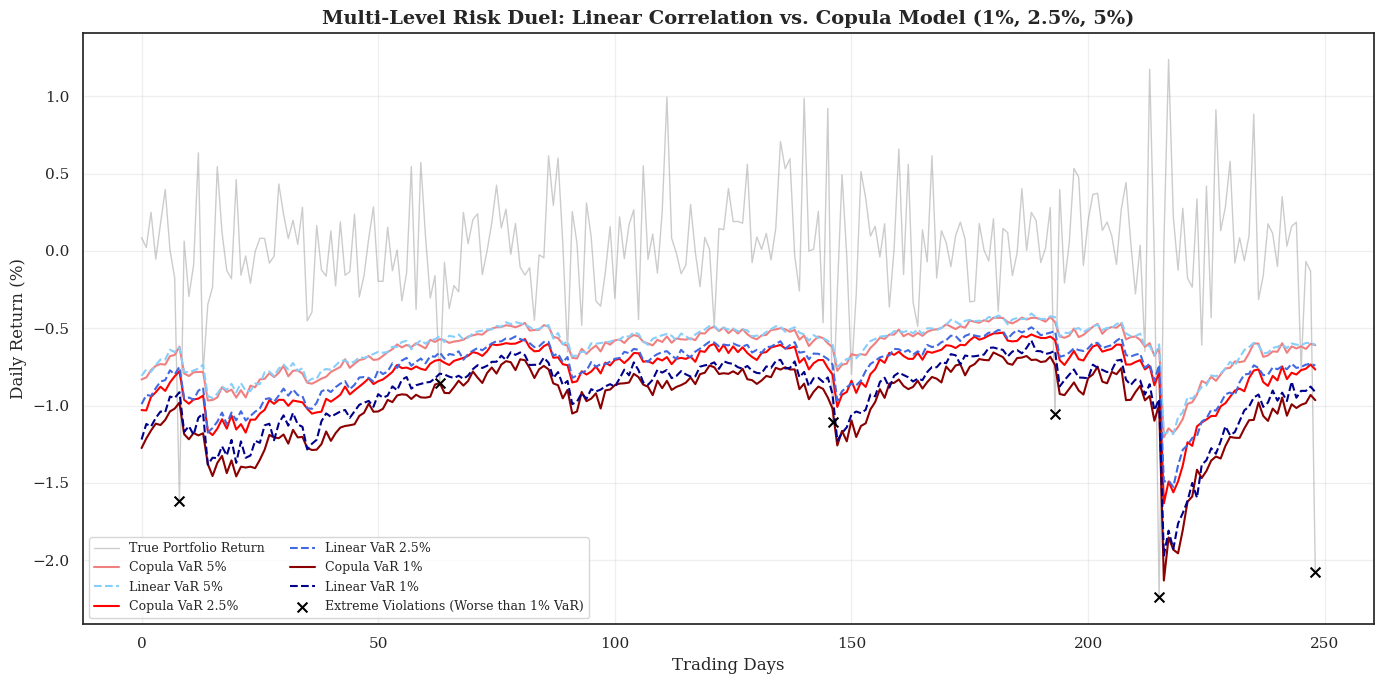

In [60]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import pearsonr
from statsmodels.distributions.copula.api import GaussianCopula, FrankCopula

# --- 0. SETUP: ESTIMATING THE LINEAR CORRELATION ---
linear_corr, _ = pearsonr(z_df['gold'], z_df['usd'])
print(f"Historical Linear Correlation (Pearson): {linear_corr:.4f}\n")

n_simulations = 5000

# We use dictionaries to store VaR arrays for multiple levels
levels = [1, 2.5, 5]
var_copula = {lvl: [] for lvl in levels}
var_linear = {lvl: [] for lvl in levels}

print("--- 1. RUNNING MULTI-LEVEL DYNAMIC VaR SIMULATIONS ---")

for t in range(test_day):
    # ==========================================
    # MODEL A: ADVANCED COPULA (Frank)
    # ==========================================
    if param_gold_usd < 0:
        sims_u_copula = FrankCopula(theta=abs(param_gold_usd)).rvs(nobs=n_simulations, random_state=t)
        sims_u_copula[:, 1] = 1 - sims_u_copula[:, 1]
    else:
        sims_u_copula = FrankCopula(theta=param_gold_usd).rvs(nobs=n_simulations, random_state=t)
        
    z_gold_copula = np.quantile(z_df['gold'], sims_u_copula[:, 0])
    z_usd_copula = np.quantile(z_df['usd'], sims_u_copula[:, 1])
    
    ret_gold_copula = z_gold_copula * vol_gold_pred[t]
    ret_usd_copula = z_usd_copula * vol_usd_pred[t]
    
    port_copula = (optimal_weight_gold * ret_gold_copula) + (optimal_weight_usd * ret_usd_copula)
    
    # Calculate all percentiles at once
    copula_percentiles = np.percentile(port_copula, levels)
    for i, lvl in enumerate(levels):
        var_copula[lvl].append(copula_percentiles[i])
    
    # ==========================================
    # MODEL B: SIMPLE LINEAR CORRELATION (Gaussian Copula)
    # ==========================================
    sims_u_linear = GaussianCopula(corr=linear_corr).rvs(nobs=n_simulations, random_state=t)
    
    z_gold_linear = np.quantile(z_df['gold'], sims_u_linear[:, 0])
    z_usd_linear = np.quantile(z_df['usd'], sims_u_linear[:, 1])
    
    ret_gold_linear = z_gold_linear * vol_gold_pred[t]
    ret_usd_linear = z_usd_linear * vol_usd_pred[t]
    
    port_linear = (optimal_weight_gold * ret_gold_linear) + (optimal_weight_usd * ret_usd_linear)
    
    # Calculate all percentiles at once
    linear_percentiles = np.percentile(port_linear, levels)
    for i, lvl in enumerate(levels):
        var_linear[lvl].append(linear_percentiles[i])

# Convert lists to numpy arrays
for lvl in levels:
    var_copula[lvl] = np.array(var_copula[lvl])
    var_linear[lvl] = np.array(var_linear[lvl])

# --- 2. BACKTESTING RESULTS FOR ALL LEVELS ---
print("--- 2. BACKTESTING RESULTS (KUPIEC TEST METRICS) ---")

true_returns_array = (optimal_weight_gold * test_gold_array) + (optimal_weight_usd * test_usd_array)
if isinstance(true_returns_array, pd.Series):
    true_returns_array = true_returns_array.values

for lvl in levels:
    target_violations = test_day * (lvl / 100)
    viol_copula = np.sum(true_returns_array < var_copula[lvl])
    viol_linear = np.sum(true_returns_array < var_linear[lvl])
    
    print(f"\n[ VaR at {lvl}% Level ({(100-lvl):.1f}% Confidence) ]")
    print(f"Target Violations Allowed : {target_violations:.1f}")
    print(f"-> Linear Model Violations: {viol_linear} (Actual Rate: {viol_linear/test_day*100:.2f}%)")
    print(f"-> Copula Model Violations: {viol_copula} (Actual Rate: {viol_copula/test_day*100:.2f}%)")

# --- 3. THE FINAL PLOT FOR YOUR THESIS ---
plt.figure(figsize=(14, 7))

# Plot true returns
plt.plot(true_returns_array, label='True Portfolio Return', color='gray', alpha=0.4, linewidth=1)

# Set up color gradients to distinguish the different risk levels
colors_copula = {5: 'lightcoral', 2.5: 'red', 1: 'darkred'}
colors_linear = {5: 'lightskyblue', 2.5: 'royalblue', 1: 'darkblue'}

for lvl in sorted(levels, reverse=True): # Plot 5% first, then 2.5%, then 1% (deepest)
    # Copula lines (Solid Red gradient)
    plt.plot(var_copula[lvl], label=f'Copula VaR {lvl}%', color=colors_copula[lvl], linewidth=1.5)
    
    # Linear lines (Dashed Blue gradient)
    plt.plot(var_linear[lvl], label=f'Linear VaR {lvl}%', color=colors_linear[lvl], linestyle='--', linewidth=1.5)

# Optional: Highlight violations for the strictest Copula VaR (1%)
indices_violations_1pct = np.where(true_returns_array < var_copula[1])[0]
if len(indices_violations_1pct) > 0:
    plt.scatter(indices_violations_1pct, true_returns_array[indices_violations_1pct], 
                color='black', s=50, zorder=5, marker='x', label='Extreme Violations (Worse than 1% VaR)')

plt.title("Multi-Level Risk Duel: Linear Correlation vs. Copula Model (1%, 2.5%, 5%)", fontweight='bold', fontsize=14)
plt.xlabel("Trading Days", fontsize=12)
plt.ylabel("Daily Return (%)", fontsize=12)

# Adjust legend to be readable without covering the chart
plt.legend(loc='lower left', fontsize=9, ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()